$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   

$ \textbf{Estudo Orientado - 2026.1}$

In [1]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter
import pandas as pd
from scipy.stats import norm, t, genpareto, genextreme
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from arch import arch_model

In [2]:
rng = np.random.default_rng(seed=4)

# Dados
Dados baixados do site https://www.nasdaq.com/market-activity/stocks/aapl/historical?page=1&rows_per_page=10&timeline=y10 

In [3]:
data = pd.read_csv("C:\\Users\\aless\\Downloads\\HistoricalData_1773786481918.csv").rename(columns={'Close/Last': 'Close'})

data['Date'] = pd.to_datetime(data['Date'])
data['Open'] = data['Open'].replace({'\$': ''}, regex=True).astype(float)
data['High'] = data['High'].replace({'\$': ''}, regex=True).astype(float)
data['Low'] = data['Low'].replace({'\$': ''}, regex=True).astype(float)
data['Close'] = data['Close'].replace({'\$': ''}, regex=True).astype(float)

data = data.set_index('Date')
series = data['Close'].pct_change().dropna()
data.head()

,Close,Volume,Open,High,Low
Date,,,,,
2026-03-16,252.82,32074210,252.105,253.885,249.88
2026-03-13,250.12,36929990,255.480,256.330,249.52
2026-03-12,255.76,40794020,258.660,258.950,254.18
2026-03-11,260.81,26218930,261.090,262.130,259.55
2026-03-10,260.83,30590770,257.645,262.480,256.95


In [4]:
pd.DataFrame(index=['Metadados'], data={
    'Série':'Preços diários da APPL', 
    'Fonte': 'Yahoo finance',
    'Período da série': '{} a {}'.format(series.index[-1].strftime('%d/%m/%Y'), series.index[0].strftime('%d/%m/%Y'))
}).T

,Metadados
Série,Preços diários da APPL
Fonte,Yahoo finance
Período da série,17/03/2016 a 13/03/2026


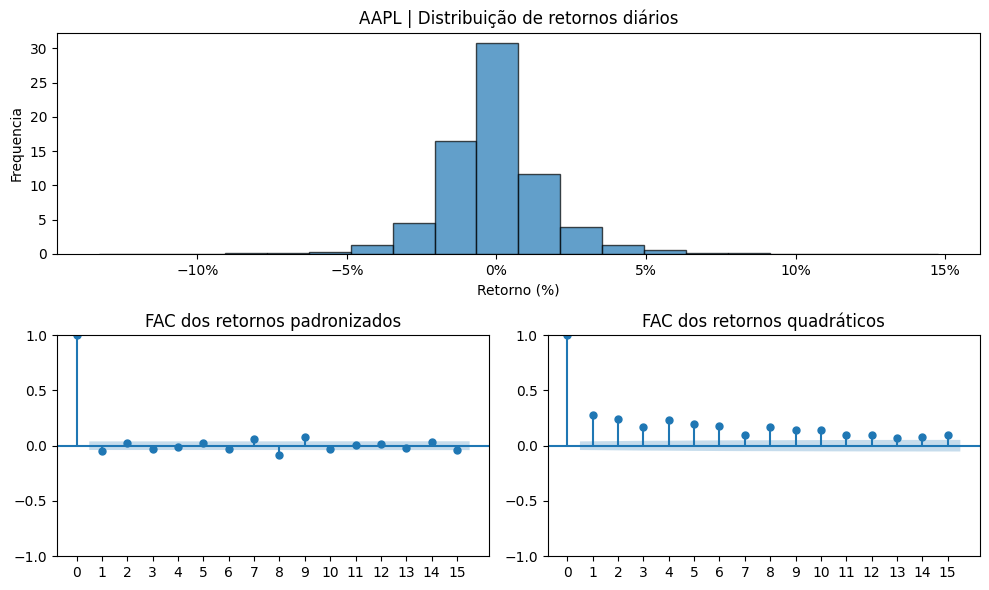

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6),
    gridspec_kw={'height_ratios': [1, 1]})

for a in ax[0]: a.remove()
ax_hist = fig.add_subplot(2, 1, 1)
ax_hist.hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
ax_hist.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax_hist.set_title('AAPL | Distribuição de retornos diários')
ax_hist.set_xlabel('Retorno (%)')
ax_hist.set_ylabel('Frequencia')

lags=15
plot_acf(series,lags=lags, ax=ax[1][0], title=f'FAC dos retornos padronizados')
ax[1][0].set_xticks(np.arange(lags+1))
ax[1][0].set_xticklabels(np.arange(lags+1))

plot_acf(series.pow(2),lags=lags, ax=ax[1][1], title=f'FAC dos retornos quadráticos')
ax[1][1].set_xticks(np.arange(lags+1))
ax[1][1].set_xticklabels(np.arange(lags+1))

fig.tight_layout()
plt.show()

# Parte 1: Modelagem dos retornos

## Normal

In [6]:
mu, std = norm.fit(series)
print('Parâmetros: \nmu={:.2f} \nstd={:.4f}'.format(mu, std))

xmin, xmax = min(series), max(series)
x = np.linspace(xmin, xmax, 100)
y_norm = norm.pdf(x, mu, std)

df_quantiles = pd.DataFrame(index=['normal','t-student','GEV','GPD'],
                           columns = ['5.0%','1.0%','0.1%'])
for alpha in [0.05, 0.01, 0.001]:
    df_quantiles.loc['normal', f'{(alpha*100)}%'] = norm.ppf(alpha, mu, std)

Parâmetros: 
mu=-0.00 
std=0.0182


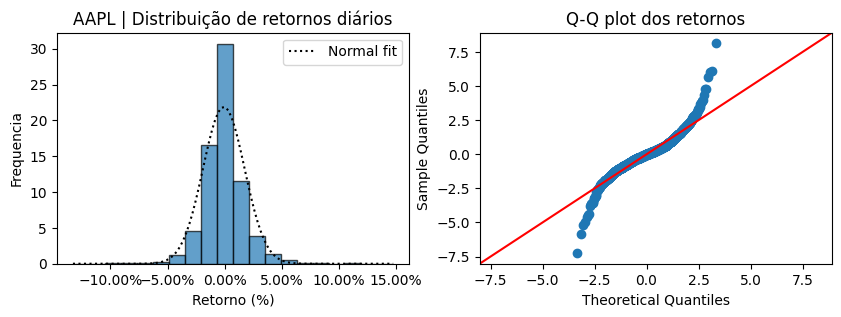

In [7]:
fig, ax = plt.subplots(1,2, figsize=(10, 3))

ax[0].plot(x, y_norm, 'k', linestyle=':', label='Normal fit')
ax[0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))
ax[0].set_title('AAPL | Distribuição de retornos diários')
ax[0].set_xlabel('Retorno (%)')
ax[0].set_ylabel('Frequencia')
ax[0].legend()

ax[1].set_title(f'Q-Q plot dos retornos')
sm.qqplot(series.sub(series.mean()).div(series.std()), ax=ax[1], line='45')

plt.show()

## t-student

In [8]:
df_t, loc_t, scale_t = t.fit(series)
y_t = t.pdf(x, df_t, loc_t, scale_t)
print('Parâmetros: \ndf={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(df_t, loc_t, scale_t))

for alpha in [0.05, 0.01, 0.001]:
    df_quantiles.loc['t-student', f'{(alpha*100)}%'] = t.ppf(alpha, df_t, loc_t, scale_t)

print('\nQuantis:')
print(df_quantiles.map(lambda v: f"{float(v):.2%}" if pd.notnull(v) else "-"))

Parâmetros: 
df=3.02 
loc=-0.0012 
scale=0.0115

Quantis:
             5.0%    1.0%     0.1%
normal     -3.07%  -4.31%   -5.70%
t-student  -2.82%  -5.32%  -11.77%
GEV             -       -        -
GPD             -       -        -


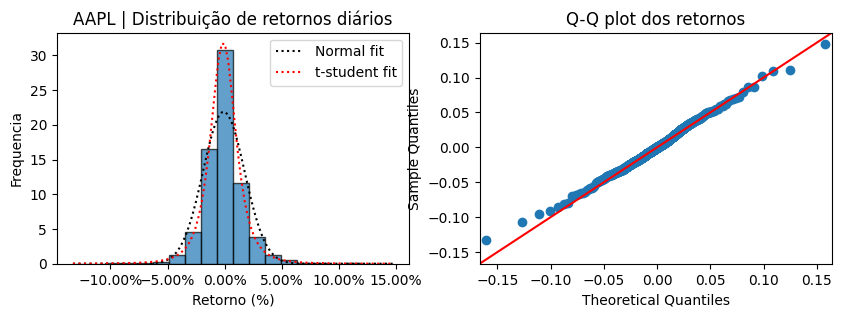

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10, 3))

ax[0].plot(x, y_norm, 'k', linestyle=':', label='Normal fit')
ax[0].plot(x, y_t, 'r', linestyle=':', label='t-student fit')
ax[0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))
ax[0].set_title('AAPL | Distribuição de retornos diários')
ax[0].set_xlabel('Retorno (%)')
ax[0].set_ylabel('Frequencia')
ax[0].legend()

ax[1].set_title(f'Q-Q plot dos retornos')
sm.qqplot(series, ax=ax[1], line='45',
          dist=t, distargs=(df_t,), loc=loc_t, scale=scale_t)

plt.show()

## GEV

In [10]:
monthly_min = series.resample('ME').min()
print(f'Quantidade de observações extremas: {monthly_min.shape[0]}')

monthly_min

Quantidade de observações extremas: 121


Date
2016-03-31   -0.023124
2016-04-30   -0.014281
2016-05-31   -0.035790
2016-06-30   -0.016562
2016-07-31   -0.061000
                ...   
2025-11-30   -0.021144
2025-12-31   -0.010797
2026-01-31   -0.038999
2026-02-28   -0.030696
2026-03-31   -0.010680
Freq: ME, Name: Close, Length: 121, dtype: float64

In [11]:
c_gev, loc_gev, scale_gev = genextreme.fit(monthly_min)
y_gev = genextreme.pdf(x, c_gev, loc_gev, scale_gev)
print('Parâmetros: \nxi={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(-c_gev, loc_gev, scale_gev))

for alpha in [0.05, 0.01, 0.001]:
    p_block = 1 - (1 - alpha)**21
    df_quantiles.loc['GEV', f'{(alpha*100)}%'] = genextreme.ppf(p_block, c_gev, loc_gev, scale_gev)

Parâmetros: 
xi=-0.78 
loc=-0.0366 
scale=0.0204


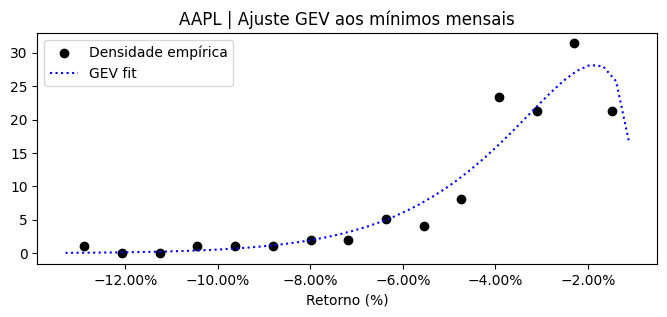

In [12]:
plt.figure(figsize=(8,3))

hist, bin_edges = np.histogram(monthly_min, bins=15, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.scatter(bin_centers, hist, color='black', label='Densidade empírica')
plt.plot(x[y_gev > 0], y_gev[y_gev > 0], 'b', linestyle=':', label='GEV fit')
plt.gca().xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))
plt.title('AAPL | Ajuste GEV aos mínimos mensais')
plt.xlabel('Retorno (%)')
plt.legend()
plt.show()

## GPD

In [36]:
thresholds = np.arange(0.01, 0.11, 0.01)
threshold_values = np.quantile(series, thresholds)
obs_below = [(series < t).sum() for t in threshold_values]
df_thresholds = pd.DataFrame({
    'Threshold (%)': thresholds * 100,
    'Threshold value (%)': threshold_values*100,
    'Obs below': obs_below
})
print(df_thresholds)

   Threshold (%)  Threshold value (%)  Obs below
0            1.0            -4.673974         26
1            2.0            -3.790053         51
2            3.0            -3.363693         76
3            4.0            -3.030058        101
4            5.0            -2.760368        126
5            6.0            -2.496504        151
6            7.0            -2.314654        176
7            8.0            -2.190142        201
8            9.0            -2.066371        226
9           10.0            -1.956697        252


In [67]:
threshold_10 = np.quantile(series, 0.05)
exceedances = threshold_10 - series[series < threshold_10]

print(f"10% threshold: {threshold_10:.2%}")
print(f'Quantidade de observações extremas: {exceedances.shape[0]}')

exceedances.head()

10% threshold: -2.76%
Quantidade de observações extremas: 126


Date
2026-02-13    0.003092
2026-01-30    0.011395
2026-01-23    0.001252
2025-10-17    0.010339
2025-09-19    0.013712
Name: Close, dtype: float64

In [68]:
xi, loc, beta = genpareto.fit(exceedances, floc=0)
y_gpd = genpareto.pdf((threshold_10 - x[x < threshold_10]), xi, loc=loc, scale=beta)
print('Parâmetros: \nxi={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(xi, loc, beta))

# cálculo do quantil para os retornos
for alpha in [0.05, 0.01, 0.001]:
    # q = threshold_10 - (beta/xi) * (((len(series)/len(exceedances))*(1 - alpha))**(xi) - 1)
    p_u = len(exceedances) / len(series)
    q = threshold_10 - (beta/xi) * ((alpha / p_u)**(-xi) - 1)
    df_quantiles.loc['GPD', f'{(alpha*100)}%'] = q

Parâmetros: 
xi=0.25 
loc=0.0000 
scale=0.0102


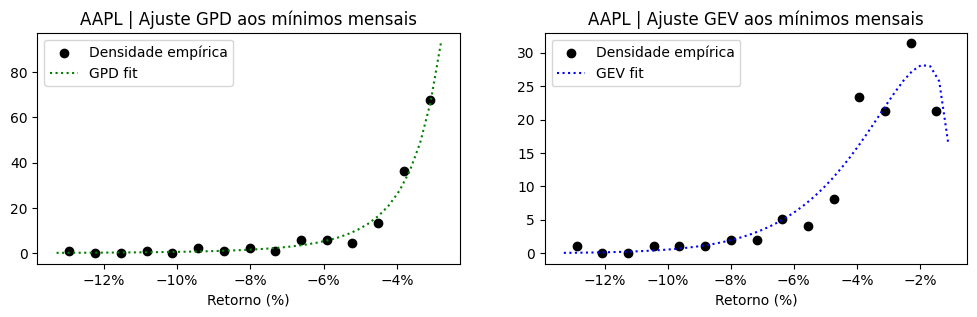

In [69]:
fig, ax = plt.subplots(1,2,figsize=(12,3))

hist, bin_edges = np.histogram(series[series < threshold_10], bins=15, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax[0].scatter(bin_centers, hist, color='black', label='Densidade empírica')
ax[0].plot(x[x < threshold_10], y_gpd, 'g', linestyle=':', label='GPD fit')
ax[0].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax[0].set_title('AAPL | Ajuste GPD aos mínimos mensais')
ax[0].set_xlabel('Retorno (%)')
ax[0].legend()

hist, bin_edges = np.histogram(monthly_min, bins=15, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax[1].scatter(bin_centers, hist, color='black', label='Densidade empírica')
ax[1].plot(x[y_gev > 0], y_gev[y_gev > 0], 'b', linestyle=':', label='GEV fit')
ax[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax[1].set_title('AAPL | Ajuste GEV aos mínimos mensais')
ax[1].set_xlabel('Retorno (%)')
ax[1].legend()

plt.show()

## Resultados

In [70]:
print(df_quantiles.map(lambda v: f"{float(v):.2%}" if pd.notnull(v) else "-"))

             5.0%    1.0%     0.1%
normal     -3.07%  -4.31%   -5.70%
t-student  -2.82%  -5.32%  -11.77%
GEV        -2.37%  -4.93%   -8.58%
GPD        -2.76%  -4.79%   -9.58%


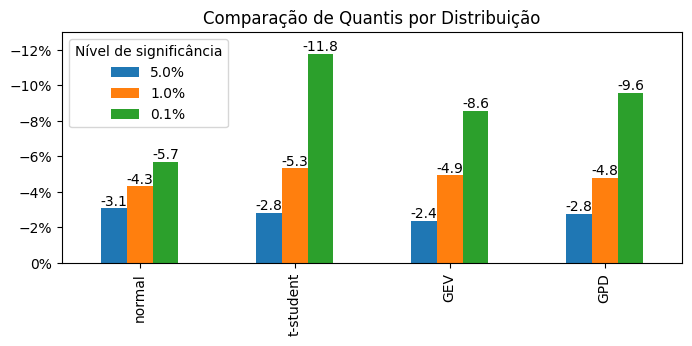

In [71]:
ax = df_quantiles.plot(kind="bar", figsize=(8,3))

ax.set_title("Comparação de Quantis por Distribuição")
ax.set_ylim(-0.13, 0)
ax.invert_yaxis()
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(title="Nível de significância")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f",
                 labels=[f"{v*100:.1f}" for v in container.datavalues])
plt.show()

# Parte 2: Modelagem dos resíduos

## AR(1)-GARCH(1,1): normal

$$
\begin{aligned}
y_t &= \mu + \phi y_{t-1} + \sigma_t z_t  , \quad  z_t \sim N(0,1) \\
\sigma_t^2 &= \omega + \alpha (y_{t-1} - \mu - \phi y_{t-2})^2 + \beta \sigma_{t-1}^2
\end{aligned}
$$

In [19]:
model_n = arch_model(series.mul(100), mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal')
model_fit_n = model_n.fit(disp='off')

resid_n = model_fit_n.resid / model_fit_n.conditional_volatility
resid_n = resid_n.dropna()

print(model_fit_n.summary())

                           AR - GARCH Model Results                           
Dep. Variable:                  Close   R-squared:                      -0.005
Mean Model:                        AR   Adj. R-squared:                 -0.005
Vol Model:                      GARCH   Log-Likelihood:               -4778.72
Distribution:                  Normal   AIC:                           9567.43
Method:            Maximum Likelihood   BIC:                           9596.58
                                        No. Observations:                 2511
Date:                Fri, Mar 27 2026   Df Residuals:                     2509
Time:                        14:55:47   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const         -0.1230  2.932e-02     -4.195  2.731e-05 

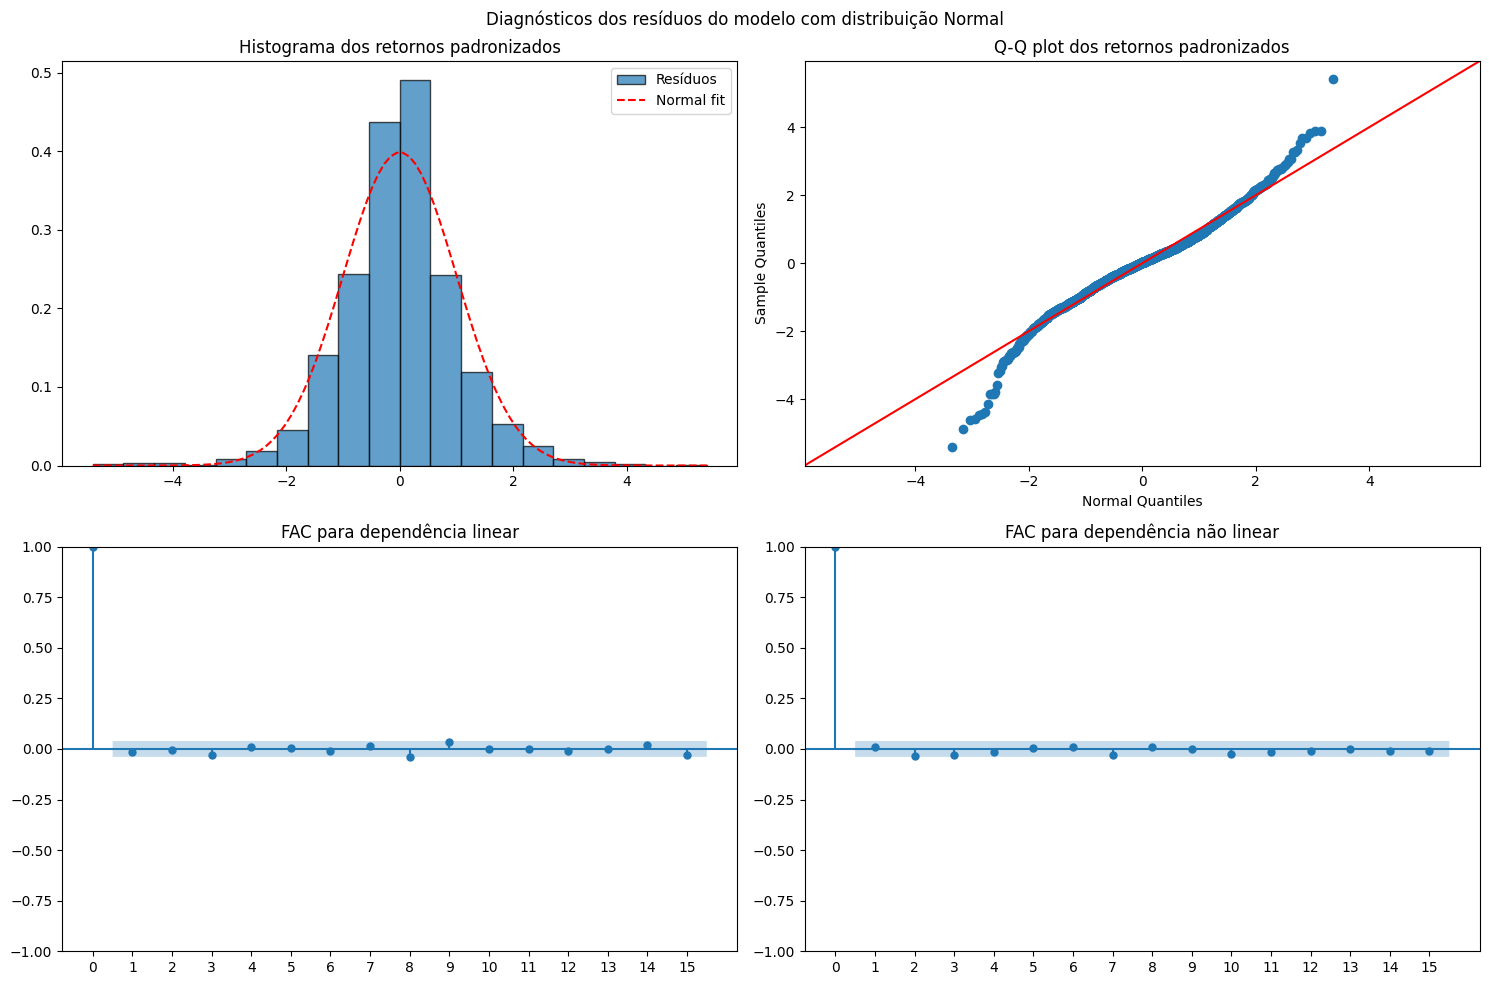

In [20]:
#diagnóstico dos resíduos padronizados
col, lags = 'Normal', 15
fig, ax = plt.subplots(2, 2, figsize=(15,10))

ax[0][0].set_title(f'Histograma dos retornos padronizados')
ax[0][0].hist(resid_n, bins=20, density=True, alpha=0.7, edgecolor='black', label='Resíduos')
x_resid = np.linspace(resid_n.min(), resid_n.max(), 100)
ax[0][0].plot(x_resid, norm.pdf(x_resid), 'r--', label='Normal fit')
ax[0][0].legend()

ax[0][1].set_title(f'Q-Q plot dos retornos padronizados')
sm.qqplot(resid_n, ax=ax[0][1], line='45')
ax[0][1].set_xlabel('Normal Quantiles')

plot_acf(resid_n,lags=lags, ax=ax[1][0], title=f'FAC para dependência linear')
ax[1][0].set_xticks(np.arange(lags+1))
ax[1][0].set_xticklabels(np.arange(lags+1))

plot_acf(resid_n.pow(2),lags=lags, ax=ax[1][1], title=f'FAC para dependência não linear')
ax[1][1].set_xticks(np.arange(lags+1))
ax[1][1].set_xticklabels(np.arange(lags+1))

plt.suptitle('Diagnósticos dos resíduos do modelo com distribuição {}'.format(col))
fig.tight_layout()
plt.show()

In [21]:
# cálculo do var
idx = pd.MultiIndex.from_product([['Normal','Student t'],['5.0%','1.0%','0.1%']])
var = pd.DataFrame(columns=idx)

mu_t = model_fit_n.params['Const'] + model_fit_n.params['Close[1]'] * series.mul(100).shift(1)
sigma_t = model_fit_n.conditional_volatility

for alpha in [0.05, 0.01, 0.001]: 
    q = model_fit_n.model.distribution.ppf(alpha)
    var[('Normal',f'{alpha:.1%}')] = mu_t + q * sigma_t

var.head()

Normal                     Student t          
                5.0%      1.0%      0.1%      5.0% 1.0% 0.1%
Date                                                        
2026-03-13       NaN       NaN       NaN       NaN  NaN  NaN
2026-03-12 -2.867205 -3.989766 -5.248041       NaN  NaN  NaN
2026-03-11 -3.002024 -4.225315 -5.596498       NaN  NaN  NaN
2026-03-10 -3.078508 -4.329701 -5.732159       NaN  NaN  NaN
2026-03-09 -2.911660 -4.067165 -5.362366       NaN  NaN  NaN

## AR(1)-GARCH(1,1): t student

$$
\begin{aligned}
y_t &= \mu + \phi y_{t-1} + \sigma_t z_t  , \quad  z_t \sim t_\nu(0,1) \\
\sigma_t^2 &= \omega + \alpha (y_{t-1} - \mu - \phi y_{t-2})^2 + \beta \sigma_{t-1}^2
\end{aligned}
$$

In [22]:
model_t = arch_model(series.mul(100), mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='studentst')
model_fit_t = model_t.fit(disp='off')

resid_t = model_fit_t.resid / model_fit_t.conditional_volatility
resid_t = resid_t.dropna()

print(model_fit_t.summary())

                              AR - GARCH Model Results                              
Dep. Variable:                        Close   R-squared:                      -0.004
Mean Model:                              AR   Adj. R-squared:                 -0.005
Vol Model:                            GARCH   Log-Likelihood:               -4670.73
Distribution:      Standardized Student's t   AIC:                           9353.46
Method:                  Maximum Likelihood   BIC:                           9388.43
                                              No. Observations:                 2511
Date:                      Fri, Mar 27 2026   Df Residuals:                     2509
Time:                              14:55:49   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
C

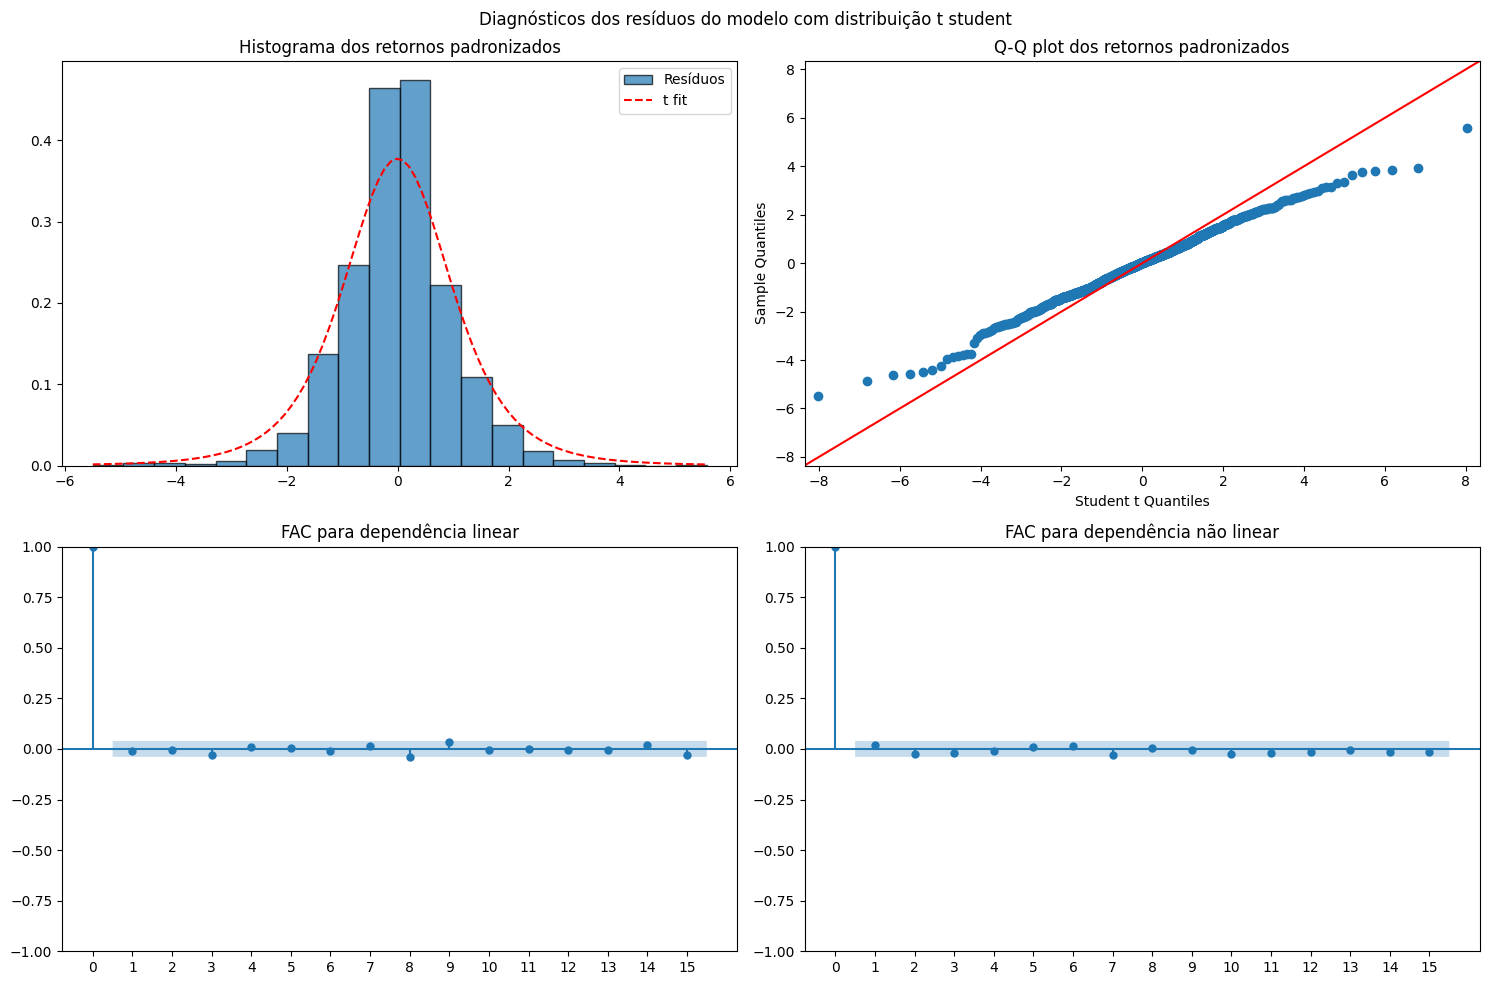

In [23]:
#diagnóstico dos resíduos padronizados
col, lags = 't student', 15
fig, ax = plt.subplots(2, 2, figsize=(15,10))

ax[0][0].set_title(f'Histograma dos retornos padronizados')
ax[0][0].hist(resid_t, bins=20, density=True, alpha=0.7, edgecolor='black', label='Resíduos')
x_resid = np.linspace(resid_t.min(), resid_t.max(), 100)
ax[0][0].plot(x_resid, t.pdf(x_resid, model_fit_t.params['nu']), 'r--', label='t fit')
ax[0][0].legend()

ax[0][1].set_title(f'Q-Q plot dos retornos padronizados')
sm.qqplot(resid_t, t, distargs=(model_fit_t.params['nu'],), ax=ax[0][1], line='45')
ax[0][1].set_xlabel('Student t Quantiles')

plot_acf(resid_t,lags=lags, ax=ax[1][0], title=f'FAC para dependência linear')
ax[1][0].set_xticks(np.arange(lags+1))
ax[1][0].set_xticklabels(np.arange(lags+1))

plot_acf(resid_t.pow(2),lags=lags, ax=ax[1][1], title=f'FAC para dependência não linear')
ax[1][1].set_xticks(np.arange(lags+1))
ax[1][1].set_xticklabels(np.arange(lags+1))

plt.suptitle('Diagnósticos dos resíduos do modelo com distribuição {}'.format(col))
fig.tight_layout()
plt.show()

In [24]:
# cálculo do var
mu_t = model_fit_t.params['Const'] + model_fit_t.params['Close[1]'] * series.mul(100).shift(1)
sigma_t = model_fit_t.conditional_volatility

for alpha in [0.05, 0.01, 0.001]: 
    q = model_fit_t.model.distribution.ppf(alpha, model_fit_t.params['nu'])
    var[('Student t',f'{alpha:.1%}')] = mu_t + q * sigma_t

var.head()

Normal                     Student t                    
                5.0%      1.0%      0.1%      5.0%      1.0%      0.1%
Date                                                                  
2026-03-13       NaN       NaN       NaN       NaN       NaN       NaN
2026-03-12 -2.867205 -3.989766 -5.248041 -2.690692 -4.486607 -8.051425
2026-03-11 -3.002024 -4.225315 -5.596498 -2.776119 -4.697182 -8.510415
2026-03-10 -3.078508 -4.329701 -5.732159 -2.848002 -4.814595 -8.718201
2026-03-09 -2.911660 -4.067165 -5.362366 -2.751421 -4.611303 -8.303094

## AR(1)-GARCH(1,1): GPD

In [25]:
threshold = np.quantile(resid_t, 0.05)
exceedances = threshold - resid_t[resid_t < threshold]

print(f"5% threshold: {threshold:.2f}%")
print(f'Quantidade de observações extremas: {exceedances.shape[0]}')

exceedances.head()

5% threshold: -1.50%
Quantidade de observações extremas: 126


Date
2026-02-13    0.444905
2026-01-30    0.520409
2026-01-23    0.032550
2025-11-10    0.114720
2025-10-24    0.475800
dtype: float64

In [26]:
xi, loc, beta = genpareto.fit(exceedances, floc=0)
# y_gpd = genpareto.pdf(threshold - x[x < threshold_10], xi, loc=loc, scale=beta)
print('Parâmetros: \nxi={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(xi, loc, beta))

# cálculo do quantil para os retornos
quantiles_gpd = {}
for alpha in [0.05, 0.01, 0.001]:
    p_u = len(exceedances) / len(resid_t)
    q = threshold - (beta/xi) * ((alpha / p_u)**(-xi) - 1)
    quantiles_gpd[alpha] = q

Parâmetros: 
xi=0.13 
loc=0.0000 
scale=0.6457


In [27]:
# cálculo do var
mu_t = model_fit_t.params['Const'] + model_fit_t.params['Close[1]'] * series.mul(100).shift(1)
sigma_t = model_fit_t.conditional_volatility

for alpha in [0.05, 0.01, 0.001]: 
    q = quantiles_gpd[alpha]
    var[('GPD',f'{alpha:.1%}')] = mu_t + q * sigma_t

var.head()

Normal                     Student t                      \
                5.0%      1.0%      0.1%      5.0%      1.0%      0.1%   
Date                                                                     
2026-03-13       NaN       NaN       NaN       NaN       NaN       NaN   
2026-03-12 -2.867205 -3.989766 -5.248041 -2.690692 -4.486607 -8.051425   
2026-03-11 -3.002024 -4.225315 -5.596498 -2.776119 -4.697182 -8.510415   
2026-03-10 -3.078508 -4.329701 -5.732159 -2.848002 -4.814595 -8.718201   
2026-03-09 -2.911660 -4.067165 -5.362366 -2.751421 -4.611303 -8.303094   

                 GPD                      
                5.0%      1.0%      0.1%  
Date                                      
2026-03-13       NaN       NaN       NaN  
2026-03-12 -2.633470 -4.541201 -8.086158  
2026-03-11 -2.714910 -4.755581 -8.547569  
2026-03-10 -2.785343 -4.874378 -8.756235  
2026-03-09 -2.692161 -4.667842 -8.339064

## Resultados

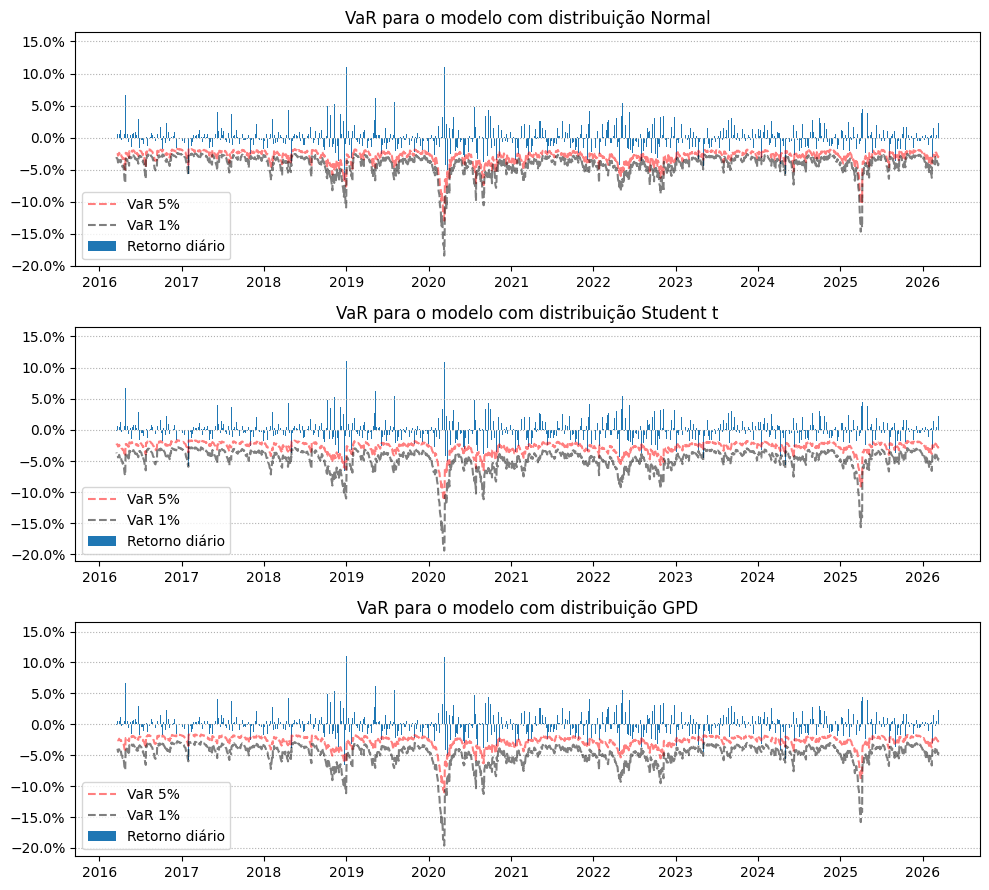

In [28]:
# gráficos do var
col = 'Normal'
fig, ax = plt.subplots(3, figsize=(10,9))
ax[0].bar(series.index, series.mul(100), width=1.0, label='Retorno diário')
ax[0].plot(var[(col, '5.0%')], label = 'VaR 5%', color = 'red', alpha=0.5, linestyle='--')
ax[0].plot(var[(col, '1.0%')], label = 'VaR 1%', color = 'black', alpha=0.5, linestyle='--')
ax[0].yaxis.set_major_formatter( mtick.PercentFormatter())
ax[0].grid(axis='y', linestyle=':')
ax[0].legend()
ax[0].set_title('VaR para o modelo com distribuição {}'.format(col))

col = 'Student t'
ax[1].bar(series.index, series.mul(100), width=1.0, label='Retorno diário')
ax[1].plot(var[(col, '5.0%')], label = 'VaR 5%', color = 'red', alpha=0.5, linestyle='--')
ax[1].plot(var[(col, '1.0%')], label = 'VaR 1%', color = 'black', alpha=0.5, linestyle='--')
ax[1].yaxis.set_major_formatter( mtick.PercentFormatter())
ax[1].grid(axis='y', linestyle=':')
ax[1].legend()
ax[1].set_title('VaR para o modelo com distribuição {}'.format(col))

col = 'GPD'
ax[2].bar(series.index, series.mul(100), width=1.0, label='Retorno diário')
ax[2].plot(var[(col, '5.0%')], label = 'VaR 5%', color = 'red', alpha=0.5, linestyle='--')
ax[2].plot(var[(col, '1.0%')], label = 'VaR 1%', color = 'black', alpha=0.5, linestyle='--')
ax[2].yaxis.set_major_formatter( mtick.PercentFormatter())
ax[2].grid(axis='y', linestyle=':')
ax[2].legend()
ax[2].set_title('VaR para o modelo com distribuição {}'.format(col))

fig.tight_layout()
plt.show()

In [29]:
# cálculo das violações
violations = pd.DataFrame(columns=var.columns)
for col in violations.columns:
    violations[col] = series.mul(100).sub(var[col]).apply(lambda x: 1 if x<0 else 0)

violations.replace({0:np.nan}).dropna(how='all').info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 125 entries, 2026-02-13 to 2016-05-13
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Normal, 5.0%)     107 non-null    float64
 1   (Normal, 1.0%)     40 non-null     float64
 2   (Normal, 0.1%)     15 non-null     float64
 3   (Student t, 5.0%)  112 non-null    float64
 4   (Student t, 1.0%)  24 non-null     float64
 5   (Student t, 0.1%)  2 non-null      float64
 6   (GPD, 5.0%)        124 non-null    float64
 7   (GPD, 1.0%)        21 non-null     float64
 8   (GPD, 0.1%)        2 non-null      float64
dtypes: float64(9)
memory usage: 9.8 KB


In [30]:
print('Violações teóricas:')
for alpha in [0.05, 0.01, 0.001]:
    print(f'{alpha:.1%}: {alpha*len(series):.0f}')

Violações teóricas:
5.0%: 126
1.0%: 25
0.1%: 3
